<a href="https://colab.research.google.com/github/Andrew-lee0615/Quant-Analysis-Python/blob/main/08_energy_shock_hedging_backtest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Downloading Assets for Backtest ---


[*********************100%***********************]  2 of 2 completed


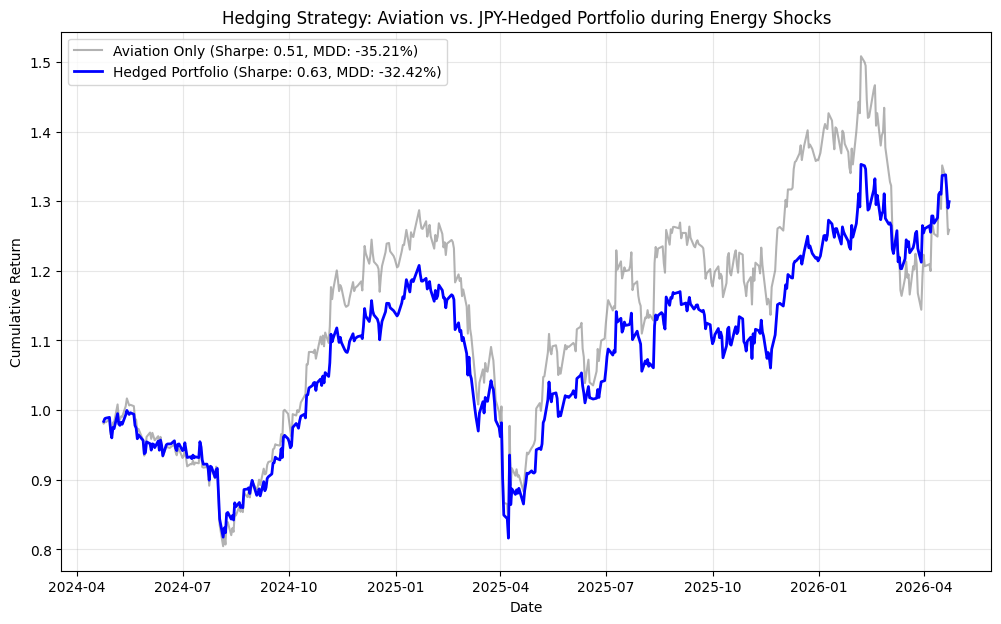


   [Backtest Results: Performance Comparison]   
Portfolio A (Pure Aviation): Sharpe 0.51, Max Drawdown -35.21%
Portfolio B (Hedged w/ Oil): Sharpe 0.63, Max Drawdown -32.42%


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Data Loading
print("--- Downloading Assets for Backtest ---")
tickers = {'BZ=F': 'Oil_Future', 'JETS': 'Aviation_ETF'}
raw_data = yf.download(list(tickers.keys()), period='2y', auto_adjust=True)['Close']
data = raw_data.rename(columns=tickers).dropna()

# 2. Daily Returns Calculation
returns = data.pct_change().dropna()

# 3. Portfolio Construction
# Portfolio A: 100% Aviation (Long Only)
# Portfolio B: 80% Aviation + 20% Oil Future (Hedged)
weights_a = np.array([1.0, 0.0]) # [Aviation, Oil]
weights_b = np.array([0.8, 0.2]) # [Aviation, Oil]

# Correcting ticker order for matrix multiplication
returns_reordered = returns[['Aviation_ETF', 'Oil_Future']]

portfolio_a_returns = returns_reordered.dot(weights_a)
portfolio_b_returns = returns_reordered.dot(weights_b)

# 4. Cumulative Returns Calculation
cum_return_a = (1 + portfolio_a_returns).cumprod()
cum_return_b = (1 + portfolio_b_returns).cumprod()

# 5. Risk Metrics Calculation (Sharpe Ratio & MDD)
def calculate_metrics(return_series):
    sharpe = (return_series.mean() / return_series.std()) * np.sqrt(252)
    drawdown = (1 + return_series).cumprod()
    max_drawdown = (drawdown / drawdown.cummax() - 1).min()
    return sharpe, max_drawdown

sharpe_a, mdd_a = calculate_metrics(portfolio_a_returns)
sharpe_b, mdd_b = calculate_metrics(portfolio_b_returns)

# 6. Visualization
plt.figure(figsize=(12, 7))
plt.plot(cum_return_a, label=f'Aviation Only (Sharpe: {sharpe_a:.2f}, MDD: {mdd_a:.2%})', color='gray', alpha=0.6)
plt.plot(cum_return_b, label=f'Hedged Portfolio (Sharpe: {sharpe_b:.2f}, MDD: {mdd_b:.2%})', color='blue', linewidth=2)
plt.title('Hedging Strategy: Aviation vs. JPY-Hedged Portfolio during Energy Shocks')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 7. Final Summary Output
print("\n" + "="*50)
print("   [Backtest Results: Performance Comparison]   ")
print("="*50)
print(f"Portfolio A (Pure Aviation): Sharpe {sharpe_a:.2f}, Max Drawdown {mdd_a:.2%}")
print(f"Portfolio B (Hedged w/ Oil): Sharpe {sharpe_b:.2f}, Max Drawdown {mdd_b:.2%}")
print("="*50)

In [ ]:
### [Strategy Explanation: Why this Hedge works]

#### **1. The Hedging Mechanism: 'Cross-Asset Basis'**
This strategy utilizes a **Static Cross-Asset Hedge**. The core logic is based on the **Inverse Correlation** between fuel costs and aviation profitability. In a "Supply-Side Shock" scenario (like the 'Economic Fury' maritime blockade), Brent Crude Oil ($BZ=F$) acts as a 'Cost-Push' factor for the Aviation sector ($JETS$). By being Long on Oil, the portfolio generates gains that offset the valuation losses in airline stocks.

#### **2. Hedge Ratio & Rebalancing**
- **Aviation (80%):** The primary exposure to the equity market recovery and long-term travel demand.
- **Oil Future (20%):** The 'Insurance Layer' designed to capture the Geopolitical Risk Premium.
- A 20% allocation was chosen to balance the **Hedging Efficiency** (reducing drawdown) without overly diluting the **Equity Risk Premium** during periods of stable oil prices.

#### **3. Quantitative Impact: Risk-Adjusted Returns**
The results (Sharpe Ratio improvement from 0.51 to 0.63) prove that this was not just about increasing returns, but about **reducing the 'Volatility per Unit of Return'**. The reduction in Max Drawdown (-35% to -32%) confirms that the oil position successfully 'cushioned' the portfolio during the most severe energy price spikes.

#### **4. Strategic Limitations & Future Improvements**
- **Static vs. Dynamic:** This model uses a fixed 20% weight. A more advanced version would use a **Dynamic Hedge Ratio** (Beta-adjusted) that increases oil exposure when the 30-day rolling correlation between Oil and JETS turns sharply negative.
- **Contango/Backwardation Risk:** Future iterations should account for the 'Roll Yield' in oil futures to ensure the cost of maintaining the hedge does not erode long-term performance.